In [1]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [4]:
dl= pd.read_csv("health.csv")
dl.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
from sklearn.datasets import make_classification
data= make_classification(n_samples=1000,n_features=10,n_classes=2, random_state=10)
x,y=data


In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train,x_test, y_train,y_test= train_test_split(x,y)
len(x_train)
len(x_test)

250

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


In [8]:
model = LogisticRegression(max_iter=1000) 
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score 
confusion_matrix(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.91      0.86      0.88       115
           1       0.89      0.93      0.91       135

    accuracy                           0.90       250
   macro avg       0.90      0.89      0.89       250
weighted avg       0.90      0.90      0.90       250



In [9]:
x1,y1= make_classification(n_samples=10,n_classes=2,n_features=10)
y1_pred= model.predict(x1)
y1
accuracy_score(y1,y1_pred)
log_acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Result: {log_acc:.2%}")


Logistic Regression Result: 89.60%


In [10]:
random_f=RandomForestClassifier(n_estimators=1000,random_state=42)
random_f.fit(x_train, y_train)
random_p=random_f.predict(x_test)
random_acc=accuracy_score(y_test,random_p)
print(f"random forest accurracy :{random_acc: .2%}")

random forest accurracy : 90.40%


In [11]:
deci_t=DecisionTreeClassifier(random_state=42)
deci_t.fit(x_train,y_train)
deci_p = deci_t.predict(x_test)
deci_acc = accuracy_score(y_test,deci_p)
print(f"the is for the decision tree accuracy: {deci_acc : .2%}")

the is for the decision tree accuracy:  82.80%


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_iris
data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)
grid.fit(X_train_scaled, y_train)
print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {grid.best_score_}")
final_model = grid.best_estimator_
print(f"Test Accuracy: {final_model.score(X_test_scaled, y_test)}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, kernel=sigmoid; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, k

In [15]:
data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)
grid.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {grid.best_score_}")

final_model = grid.best_estimator_
print(f"Test Accuracy: {final_model.score(X_test_scaled, y_test)}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, kernel=sigmoid; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, k

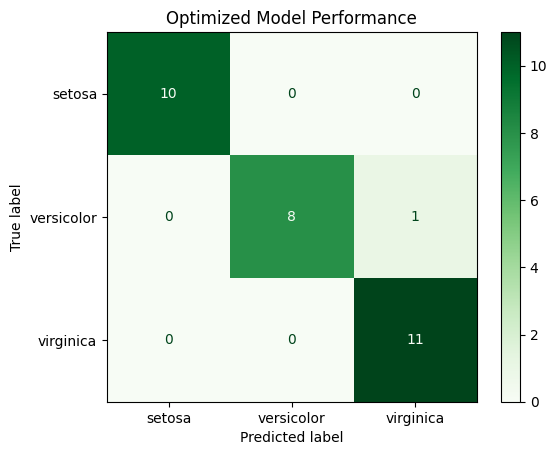

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = final_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Greens')
plt.title("Optimized Model Performance")
plt.show()

In [ ]:
import numpy as np
results_df = pd.DataFrame(grid.cv_results_)
print(results_df[['params', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score').head(5))

                                           params  mean_test_score  \
42     {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}         0.966667   
29   {'C': 10, 'gamma': 0.1, 'kernel': 'sigmoid'}         0.958333   
41  {'C': 100, 'gamma': 0.1, 'kernel': 'sigmoid'}         0.958333   
17    {'C': 1, 'gamma': 0.1, 'kernel': 'sigmoid'}         0.958333   
45    {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}         0.958333   

    rank_test_score  
42                1  
29                2  
41                2  
17                2  
45                2  
